In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn


In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 3060 Laptop GPU
11.8
['sm_37', 'sm_50', 'sm_60', 'sm_61', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'compute_37']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import numpy as np

seed = 4
torch.manual_seed(seed)
np.random.seed(seed)

torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
exclude_rgb_vis=False
exclude_weather_features=True
exclude_canopy_temp=True
dataset_name = "stratified_train_test_datasets_v3.xlsx"

In [5]:
from features import *

vi_features = get_vi_features(exclude_rgb_vis=exclude_rgb_vis)
weather_features = get_weather_features(exclude=exclude_weather_features)
canopy_temp_features = get_canopy_temp_features(exclude=exclude_canopy_temp)
features = vi_features + weather_features + canopy_temp_features

output_variable = get_output_variable()

Text(0.5, 1.0, 'Train vs Test Yield Distribution')

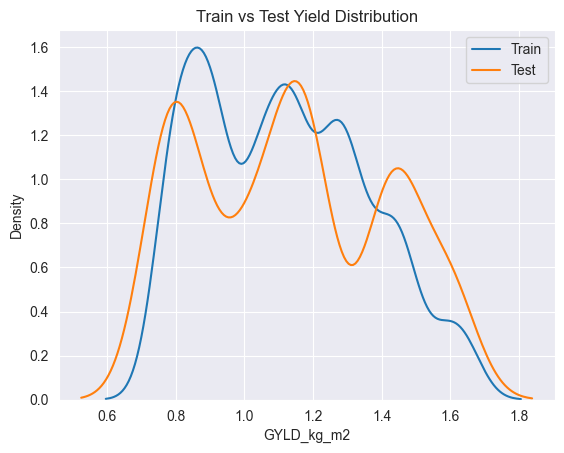

In [6]:
# Loading saved training test
train_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Train')
test_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [9]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1167
test_df_scaled Rows with at least one NaN: 364


In [10]:
# print(X_test_scaled.shape)

In [11]:

def train_data(model, model_train_loader, num_epochs, learning_rate, weight_decay, hyper_param_criterion_method, file_save_name, early_stopping = False):
    best_train_loss  = float('inf')
    patience = 20
    counter = 0

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    if hyper_param_criterion_method == "MSE":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=1)

    total_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch, lengths in model_train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            lengths = lengths.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch, lengths)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(model_train_loader.dataset)
        total_loss.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.5f}")

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            if file_save_name != "":
                torch.save(model.state_dict(), file_save_name)
            counter = 0
        elif early_stopping:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return total_loss


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def evaluate_model(model, val_loader, output_variable_scaler, do_inverse_transform = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_hat = model(X_batch, lengths)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if do_inverse_transform:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    if plot_pred_vs_true:
        plt.figure(figsize=(8,6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.xlabel("Actual Yield")
        plt.ylabel("Predicted Yield")
        plt.title("LSTM Predictions vs Actual")
        plt.show()

    return r2, mse, mae

In [9]:
def predict_yield(model, val_loader, output_variable_scaler, do_inverse_transform = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch, lengths in val_loader:
            X_batch = X_batch.to(device)
            lengths = lengths.to(device)
            y_hat = model(X_batch, lengths)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if do_inverse_transform:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    return y_true, y_pred

In [10]:
window_size = 30
pad_value = 0

In [11]:
from torch.nn.utils.rnn import pack_padded_sequence
from helper import make_progressive_windows
from vi_dataset import VIDataset
from model_definitions import  GRUModel
from torch.utils.data import DataLoader

def validation_with_test(trial_id, batch_size, epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    X_train_scaled, y_train_scaled, lengths_train, no_days_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

    X_test_scaled, y_test_scaled, lengths_test, no_days_test = make_progressive_windows(
        dataframe=test_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

    train_dataset = VIDataset(X_train_scaled, y_train_scaled, lengths_train)
    test_dataset = VIDataset(X_test_scaled, y_test_scaled, lengths_test)

    train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1 , dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader,
        num_epochs = epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse, mae = evaluate_model(
        model = model,
        val_loader = test_loader,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [16]:
import optuna
from sklearn.metrics import r2_score

epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=180)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

In [12]:
# =============================================
#  Train the best model with best hyper params
# =============================================
from model_definitions import GRUModel


# Best R²: 0.2857
# saved as /best_gru_models/best_model_hyper_param_3.pth
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.07420456457400194, 'lr': 0.00981026753766152, 'weight_decay': 8.506150589531528e-08, 'batch_size': 16}

# Best R²: 0.18 not good
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = -99
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.01882176215855477, 'lr': 0.007580682214882081, 'weight_decay': 1.416934618280146e-06, 'batch_size': 64}

# Best R²: 0.2585 not good
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: True;  Make sure GRU model use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 8, 'num_layers': 1, 'dropout': 0.47771061284348876, 'lr': 0.007432078216397578, 'weight_decay': 2.757922254289341e-07, 'batch_size': 32}

# Best R²: 0.5396, Test MSE: 0.0347
# saved as /best_gru_models/best_model_hyper_param_5.pth
# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
best_gru_params = {'hidden_size': 8, 'num_layers': 2, 'dropout': 0.4116615584951404, 'lr': 0.00011452360758206809, 'weight_decay': 2.955054638657815e-08, 'batch_size': 8}


# best_gru_params = {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.4976259917429097, 'lr': 0.0008701386766216585, 'weight_decay': 2.7353019000288583e-08, 'batch_size': 64}

# Dataset: v3
# Features: All the VIs in v3 dataset
# Masking/Length in GRU: False;  Make sure GRU model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# window size = 45
# best_gru_params = {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.320229941193197, 'lr': 0.0016697538740409186, 'weight_decay': 3.6460180053638094e-06, 'batch_size': 8}



best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [13]:
from helper import make_progressive_windows
from vi_dataset import VIDataset
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

X_train_scaled, y_train_scaled, valid_length_train, no_days_train  = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled, valid_length_test, no_days_test = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

Processing plot 10_d
Processing plot 10_w
Processing plot 11_d
Processing plot 11_w
Processing plot 12_d
Processing plot 12_w
Processing plot 13_d
Processing plot 13_w
Processing plot 14_w
Processing plot 15_d
Processing plot 15_w
Processing plot 16_w
Processing plot 17_d
Processing plot 18_d
Processing plot 19_d
Processing plot 19_w
Processing plot 1_w
Processing plot 20_w
Processing plot 21_d
Processing plot 21_w
Processing plot 22_w
Processing plot 23_d
Processing plot 24_d
Processing plot 24_w
Processing plot 2_d
Processing plot 2_w
Processing plot 3_d
Processing plot 3_w
Processing plot 4_d
Processing plot 5_d
Processing plot 5_w
Processing plot 6_d
Processing plot 7_w
Processing plot 8_d
Processing plot 8_w
Processing plot 9_d
Processing plot 9_w
Processing plot 14_d
Processing plot 16_d
Processing plot 17_w
Processing plot 18_w
Processing plot 1_d
Processing plot 20_d
Processing plot 23_w
Processing plot 4_w
Processing plot 6_w
Processing plot 7_d


In [14]:

train_dataset = VIDataset(X_train_scaled, y_train_scaled, valid_length_train)
test_dataset = VIDataset(X_test_scaled, y_test_scaled, valid_length_test)


train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)

In [ ]:
# Optional: Train again with best hyper parameters

epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

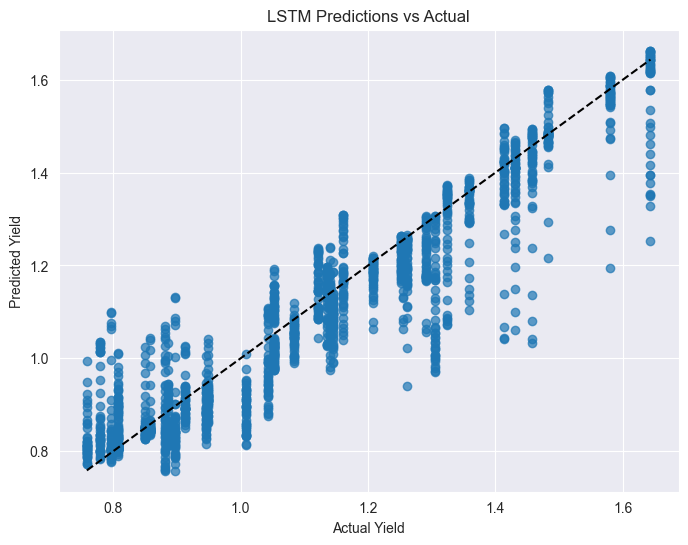

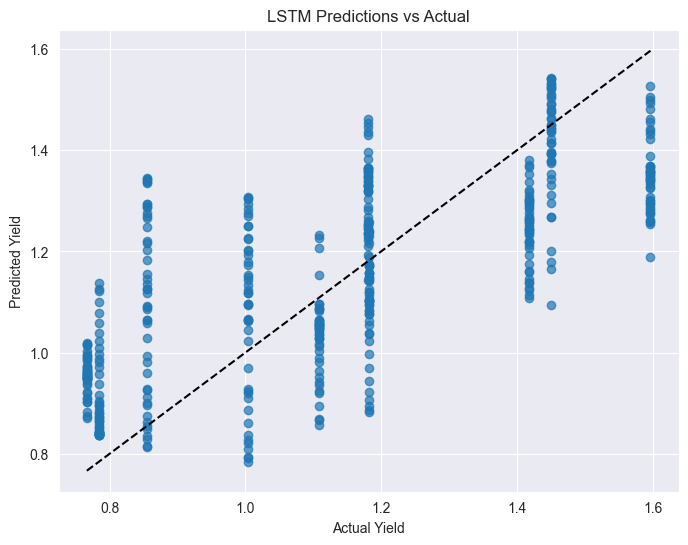

Train R²: 0.8589, Train MSE: 0.0081
Test R²: 0.5397, Test MSE: 0.0347


In [15]:
# from train_eval_functions import evaluate_model

best_model.load_state_dict(torch.load("best_gru_models/best_model_hyper_param_5.pth", map_location=device))

# Training metrics
r2_train, mse_train, mae_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test, mae_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [ ]:
from helper import filter_window_data_by_length

total_n_days = 46 # (from may 1st to June 15th)

test_r2 = []
test_mse = []
test_mae = []
for filter_day in range(1, total_n_days + 1):
    print(f"day: {filter_day}")

    X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered = filter_window_data_by_length(
    X_train_scaled, y_train_scaled, valid_length_train, no_days_train, filter_day
    )

    # test
    X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered = filter_window_data_by_length(
        X_test_scaled, y_test_scaled, valid_length_test, no_days_test, filter_day
    )

    train_dataset_filtered = VIDataset(X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered)
    test_dataset_filtered = VIDataset(X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered)

    train_loader_filtered  = DataLoader(train_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=True)
    test_loader_filtered    = DataLoader(test_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=False)

    # Training metrics
    r2_train_filtered, mse_train_filtered, mae_train_filtered = evaluate_model(best_model, train_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)
    # Test metrics
    r2_test_filtered, mse_test_filtered, mae_test_filtered = evaluate_model(best_model, test_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)

    print(f'Train R²: {r2_train_filtered:.4f}, Train MSE: {mse_train_filtered:.4f}, Train MAE: {mae_train_filtered:.4f}')
    print(f'Test R²: {r2_test_filtered:.4f}, Test MSE: {mse_test_filtered:.4f}, Test MAE: {mae_test_filtered:.4f}')
    test_r2.append(r2_test_filtered)
    test_mse.append(mse_test_filtered)
    test_mae.append(mae_test_filtered)


In [48]:
import numpy as np

print(np.mean(test_r2))
print(np.min(test_r2))
print(np.max(test_r2))

print(np.mean(test_mse))
print(np.max(test_mse))
print(np.min(test_mse))

print(np.mean(test_mae))
print(np.max(test_mae))
print(np.min(test_mae))

0.5396838097468667
0.08806484937667847
0.7620068788528442
0.03465733519228904
0.06865985691547394
0.01791856810450554
0.1554121776767399
0.23037020862102509
0.10501332581043243


In [46]:
START_DAY = 122 # May 1st in gregorian days

def plot_r(r2_list, total_n_days):
    x = np.arange(START_DAY, START_DAY + total_n_days)
    max_idx = np.argmax(r2_list)
    max_x = x[max_idx]
    max_y = r2_list[max_idx]
    max_y_rounded = round(max_y, 4)
    r2_copy = np.delete(r2_list, max_idx)  # remove max
    second_max_val = np.max(r2_copy)
    second_max_idx = np.where(r2_list == second_max_val)[0][0]
    second_max_x = x[second_max_idx]
    second_max_y_rounded = round(second_max_val, 4)
    plt.figure(figsize=(12, 4))
    plt.plot(x, r2_list, marker='o')
    plt.scatter(max_x, max_y, color='red', s=80, zorder=5)
    plt.text(max_x, max_y, f" {max_y_rounded} at day {max_x}", color='red', fontsize=10, va='bottom')
    plt.scatter(second_max_x, second_max_val, color='red', s=80, zorder=5)
    plt.text(second_max_x, second_max_val, f"  {second_max_y_rounded} at day {second_max_x}", color='red',
             fontsize=10, va='bottom')
    plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    plt.axvline(x=143, color='gray', linestyle='--', linewidth=1,
                label='Heading date')
    plt.xlabel("Day (Gregorian days)")
    plt.ylabel("Test R²")
    # plt.title("Test R² over days")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

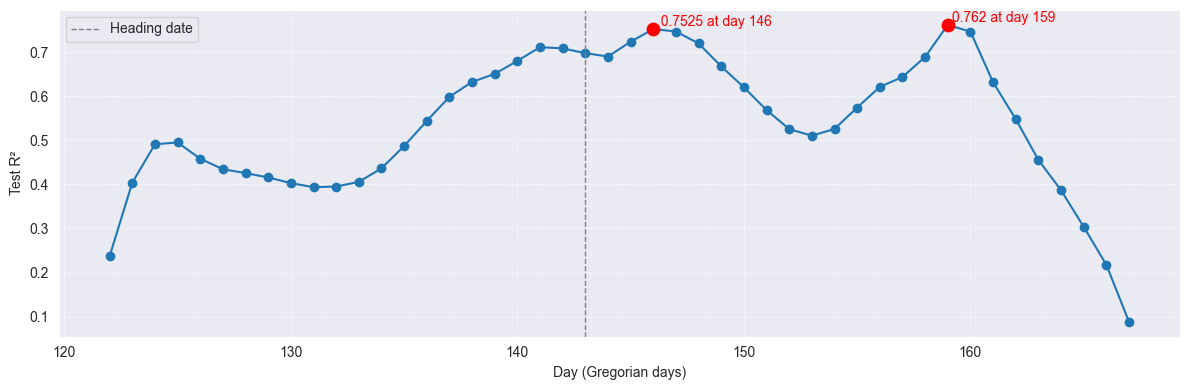

In [47]:
plot_r(test_r2, total_n_days)

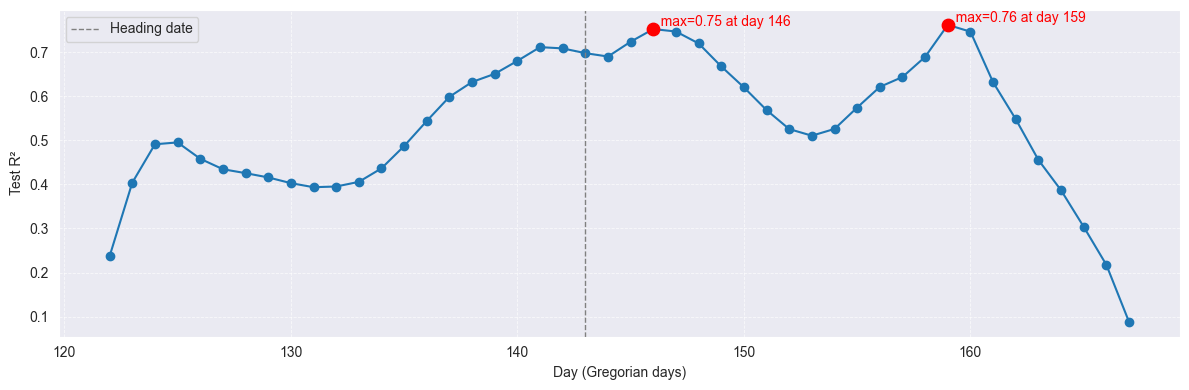

In [34]:
from plots import plot_r2, plot_mse

plot_r2(test_r2, total_n_days)
plot_mse(test_mse, total_n_days)

In [20]:
test_plot_14d = test_df_scaled[test_df_scaled["plot_id"] == "14_d"]
test_plot_14d

,date,plot_id,ndvi_noir_rgb_method,gndvi_noir_rgb_method,rdvi_noir_rgb_method,savi_noir_rgb_method,sr_noir_rgb_method,evi_noir_rgb_method,cigreen_noir_rgb_method,gli,...,lepton_mean_temp,lepton_min_temp,lepton_max_temp,Solar,Precipitation,AirTemp,Vapor_Pressure,AtmPressure,RelHumidity,GYLD_kg_m2
0,2024-05-01,14_d,-0.351645,-0.753008,-0.377877,-0.379236,-0.487110,-0.329485,-0.784549,-0.432326,...,24.460153,20.674524,30.479355,844.833333,0.00000,12.400000,0.646667,97.566667,0.451000,0.15295
1,2024-05-02,14_d,-0.252322,-0.658197,-0.271253,-0.270593,-0.403270,-0.213987,-0.710197,-0.326990,...,34.736689,33.169168,36.319429,835.083333,0.00000,14.600000,0.729167,97.191667,0.441750,0.15295
2,2024-05-03,14_d,0.377677,0.021867,0.512292,0.558237,0.188170,0.657529,-0.135875,0.369134,...,17.662139,16.705180,19.636209,824.333333,0.00000,16.058333,0.830000,97.266667,0.458167,0.15295
3,2024-05-04,14_d,0.695364,0.354921,0.948684,1.030866,0.496723,1.177263,0.151837,0.687729,...,18.804566,18.060429,19.805159,269.166667,0.00000,16.100000,1.040000,95.725000,0.572667,0.15295
4,2024-05-05,14_d,0.837683,0.503083,1.146540,1.245608,0.637108,1.406020,0.281469,0.873365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15295
5,2024-05-06,14_d,0.373282,-0.024087,0.535559,0.590920,0.185567,0.703282,-0.172595,0.440589,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15295
6,2024-05-07,14_d,0.183680,-0.228764,0.232125,0.252263,-0.009343,0.346131,-0.356365,0.120499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15295
7,2024-05-08,14_d,0.280785,-0.129129,0.229745,0.216371,0.072224,0.302865,-0.277592,0.023894,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15295
8,2024-05-09,14_d,0.358178,-0.060026,0.280490,0.257629,0.136433,0.381160,-0.225165,-0.157665,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15295
9,2024-05-10,14_d,0.167943,-0.347607,0.107798,0.091810,-0.031834,0.299515,-0.455561,-0.577318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15295


In [21]:
X_test_plot_scaled, y_test_plot_scaled, valid_length_test_plot, no_days_test_plot = make_progressive_windows(
    dataframe=test_plot_14d,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

Processing plot 14_d


In [22]:
total_n_days = 46 # (from may 1st to June 15th)

y_pred_list = []
y_true_list = []

for filter_day in range(1, total_n_days + 1):
    print(f"day: {filter_day}")

    X_test_plot_scaled_filtered, y_test_plot_scaled_filtered, lengths_test_plot_filtered = filter_window_data_by_length(
        X_test_plot_scaled, y_test_plot_scaled, valid_length_test_plot, no_days_test_plot, filter_day
    )

    test_plot_dataset_filtered = VIDataset(X_test_plot_scaled_filtered, y_test_plot_scaled_filtered, lengths_test_plot_filtered)
    test_plot_loader_filtered    = DataLoader(test_plot_dataset_filtered, batch_size=best_gru_params['batch_size'], shuffle=False)

    # Test metrics
    y_true, y_predicted = predict_yield(best_model, test_plot_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)

    print(y_true, y_predicted)

    y_pred_list.append(float(y_predicted[0]))
    y_true_list.append(float(y_true[0]))

actual_yield = y_true_list[0]

day: 1
[[1.1822]] [[1.0377722]]
day: 2
[[1.1822]] [[1.053846]]
day: 3
[[1.1822]] [[1.1129493]]
day: 4
[[1.1822]] [[1.1481094]]
day: 5
[[1.1822]] [[1.1724685]]
day: 6
[[1.1822]] [[1.1576544]]
day: 7
[[1.1822]] [[1.1251816]]
day: 8
[[1.1822]] [[1.1040188]]
day: 9
[[1.1822]] [[1.0933125]]
day: 10
[[1.1822]] [[1.0821117]]
day: 11
[[1.1822]] [[1.0757744]]
day: 12
[[1.1822]] [[1.0760558]]
day: 13
[[1.1822]] [[1.0846014]]
day: 14
[[1.1822]] [[1.0932947]]
day: 15
[[1.1822]] [[1.0997165]]
day: 16
[[1.1822]] [[1.1019629]]
day: 17
[[1.1822]] [[1.1018151]]
day: 18
[[1.1822]] [[1.1009886]]
day: 19
[[1.1822]] [[1.1064562]]
day: 20
[[1.1822]] [[1.1201143]]
day: 21
[[1.1822]] [[1.1499734]]
day: 22
[[1.1822]] [[1.1712157]]
day: 23
[[1.1822]] [[1.1750116]]
day: 24
[[1.1822]] [[1.1708033]]
day: 25
[[1.1822]] [[1.1571916]]
day: 26
[[1.1822]] [[1.1441387]]
day: 27
[[1.1822]] [[1.1424446]]
day: 28
[[1.1822]] [[1.1582447]]
day: 29
[[1.1822]] [[1.1890557]]
day: 30
[[1.1822]] [[1.229552]]
day: 31
[[1.1822]] [[

C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_17396\1838233581.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_list.append(float(y_predicted[0]))
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_17396\1838233581.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_true_list.append(float(y_true[0]))
C:\Users\lochana.marasingha\AppData\Local\Temp\ipykernel_17396\1838233581.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_pred_li

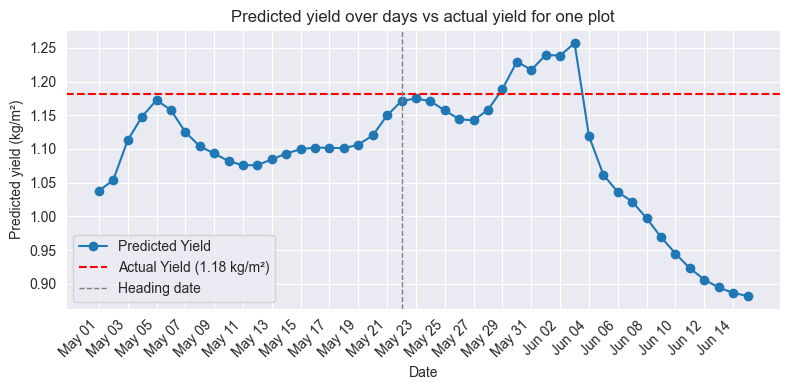

In [23]:
from plots import plot_predicted_yield
import numpy as np
import datetime as dt

# For drought plots the mean heading date is at 143 gregorian day

# plot_predicted_yield(total_n_days, y_pred_list, actual_yield)


x = np.arange(122, 122 + total_n_days)

date_labels = [(dt.date(2024, 1, 1) + dt.timedelta(days=int(day)-1)).strftime("%b %d")
               for day in x]

differences = np.abs(np.array(y_pred_list) - actual_yield)
closest_idx = np.argmin(differences)

closest_day = x[closest_idx]
closest_pred = y_pred_list[closest_idx]


plt.figure(figsize=(8, 4))
plt.plot(x, y_pred_list, marker='o', label='Predicted Yield')

plt.axhline(actual_yield, linestyle='--', label=f'Actual Yield ({actual_yield:.2f} kg/m²)', color='r')
# plt.scatter(closest_day, closest_pred, s=120, edgecolors='black',
#             label=f'Closest Predicted Yield ({closest_pred:.2f} kg/m²) at day {closest_day}', zorder=5)
plt.axvline(x=143, color='gray', linestyle='--', linewidth=1,
            label='Heading date')
tick_indices = np.arange(0, len(x), 2)   # every 6th point
tick_values = x[tick_indices]
tick_labels = [date_labels[i] for i in tick_indices]


plt.xlabel("Date")
plt.ylabel("Predicted yield (kg/m²)")
plt.xticks(ticks=tick_values, labels=tick_labels, rotation=45, ha='right')

plt.title("Predicted yield over days vs actual yield for one plot")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_5.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_5.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_5.save")